# Maven — point-in-time features and chronological baselines
## 1. Independent loading and static features
No dependency on another notebook's kernel. Account revenue is millions of USD; revenue/employee converts to USD. Annual founding precision gives approximate company age. Negative ages are missing, not clipped to zero. All static fields assume reference snapshots reflect engagement-time values. No current outcome fields enter model matrices.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'CONTEXT.md').is_file() and (p/'datasets').is_dir())
DATA = ROOT/'datasets'/'CRM+Sales+Opportunities'
read = lambda n: pd.read_csv(DATA/(n+'.csv'), keep_default_na=False, na_values=['']).drop_duplicates()
p, a, pr, st = [read(n) for n in ['sales_pipeline','accounts','products','sales_teams']]
assert p.opportunity_id.is_unique and a.account.is_unique and pr['product'].is_unique and st.sales_agent.is_unique
assert 'GTXPro' not in set(pr['product']) and 'GTX Pro' in set(pr['product'])
assert [v for v in pr['product'] if ''.join(v.split())=='GTXPro'] == ['GTX Pro']
p['product'] = p['product'].replace({'GTXPro':'GTX Pro'})
base = p.merge(a,on='account',how='left',validate='many_to_one').merge(pr,on='product',how='left',validate='many_to_one').merge(st,on='sales_agent',how='left',validate='many_to_one')
for c in ['engage_date','close_date']: base[c] = pd.to_datetime(base[c],format='%Y-%m-%d')
eligible = base.account.isin(a.account) & base['product'].isin(pr['product']) & base.sales_agent.isin(st.sales_agent) & base.engage_date.notna()
closed = base.loc[eligible & base.deal_stage.isin(['Won','Lost']) & base.close_date.notna() & (base.close_date>=base.engage_date)].copy().reset_index(drop=True)
closed['target'] = closed.deal_stage.map({'Won':1,'Lost':0}).astype(int)
assert len(closed)==6711
def static_features(frame):
    f=frame.copy()
    age=f.engage_date.dt.year-f.year_established
    f['company_age_at_engagement']=age.where(age>=0)
    f['founding_inconsistent']=(age<0).astype(int)
    f['log_account_revenue']=np.log1p(f.revenue)
    f['log_employee_count']=np.log1p(f.employees)
    f['revenue_per_employee']=f.revenue*1e6/f.employees.where(f.employees>0)
    f['log_revenue_per_employee']=np.log1p(f.revenue_per_employee)
    f['subsidiary_indicator']=f.subsidiary_of.notna().astype(int)
    f['engagement_month']=f.engage_date.dt.month
    f['engagement_quarter']=f.engage_date.dt.quarter
    f['log_sales_price']=np.log1p(f.sales_price)
    return f
model=static_features(closed)
open_opportunities=base.loc[~base.deal_stage.isin(['Won','Lost'])].copy()
scoreable_open=static_features(base.loc[eligible & base.deal_stage.eq('Engaging')])
pd.set_option('display.max_columns',25)
print('Usable closed:',len(model),'| open preserved:',len(open_opportunities),'| contract-eligible open:',len(scoreable_open))
display(model[['company_age_at_engagement','log_account_revenue','log_employee_count','revenue_per_employee','log_revenue_per_employee','subsidiary_indicator','engagement_month','engagement_quarter']].agg(['min','median','max']).T)

Usable closed: 6711 | open preserved: 2089 | contract-eligible open: 501


,min,median,max
company_age_at_engagement,0.000000,22.000000,3.800000e+01
log_account_revenue,1.711995,7.437913,9.367261e+00
log_employee_count,2.302585,8.161375,1.044258e+01
revenue_per_employee,273103.056471,453900.000000,1.181803e+06
log_revenue_per_employee,12.517608,13.025634,1.398255e+01
subsidiary_indicator,0.000000,0.000000,1.000000e+00
engagement_month,1.000000,7.000000,1.200000e+01
engagement_quarter,1.000000,3.000000,4.000000e+00


## 2. Strictly prior outcome histories
For each entity, binary-search the closing-date-sorted ledger with side='left': same-day closes are excluded. Counts/rates are cumulative over **close_date < engage_date**; no-history rates/recency stay missing and explicit presence flags remain. Audit the latest contributing close and verify sample rows against brute-force filtering. This is rolling inference with a frozen model: earlier validation/test outcomes may update history only after they close, as an operational CRM would. A frozen-ledger test diagnostic is also reported. Pair histories are omitted to avoid sparse feature expansion in this first baseline.

In [2]:
def add_histories(frame,ledger):
    result=frame.copy()
    for key,prefix in [('account','account'),('sales_agent','agent'),('product','product')]:
        count=np.zeros(len(frame),dtype=int); wins=np.zeros(len(frame),dtype=int)
        last=np.full(len(frame),np.datetime64('NaT','ns'),dtype='datetime64[ns]')
        for value,positions in frame.groupby(key).indices.items():
            old=ledger.loc[ledger[key].eq(value)].sort_values('close_date')
            dates=old.close_date.to_numpy(dtype='datetime64[ns]')
            score_dates=frame.iloc[positions].engage_date.to_numpy(dtype='datetime64[ns]')
            n=np.searchsorted(dates,score_dates,side='left')
            count[positions]=n
            cumulative=np.r_[0,old.target.to_numpy().cumsum()]
            wins[positions]=cumulative[n]
            has=n>0
            last[positions[has]]=dates[n[has]-1]
        result[prefix+'_prior_closed_count']=count
        result[prefix+'_prior_win_count']=wins
        result[prefix+'_prior_win_rate']=np.divide(wins,count,out=np.full(len(frame),np.nan),where=count>0)
        result[prefix+'_history_present']=(count>0).astype(int)
        result[prefix+'_last_close']=last
        result[prefix+'_days_since_close']=(result.engage_date-pd.Series(last,index=result.index)).dt.days
        assert ((result[prefix+'_last_close']<result.engage_date) | result[prefix+'_last_close'].isna()).all()
        assert result.loc[count==0,prefix+'_prior_win_rate'].isna().all()
    return result
model=add_histories(model,closed)
scoreable_open=add_histories(scoreable_open,closed)
for _,row in model.sample(25,random_state=42).iterrows():
    for key,prefix in [('account','account'),('sales_agent','agent'),('product','product')]:
        prior=closed.loc[closed[key].eq(row[key]) & (closed.close_date<row.engage_date)]
        assert len(prior)==row[prefix+'_prior_closed_count']
        assert prior.target.sum()==row[prefix+'_prior_win_count']
        assert row.opportunity_id not in set(prior.opportunity_id)
display(model[[c for c in model if c.endswith(('prior_closed_count','prior_win_rate','history_present'))]].describe().round(3))
print('Strict-date/self-exclusion/brute-force checks passed; missing history remains unknown.')

,account_prior_closed_count,account_prior_win_rate,account_history_present,agent_prior_closed_count,agent_prior_win_rate,agent_history_present,product_prior_closed_count,product_prior_win_rate,product_history_present
count,6711.000,5632.000,6711.000,6711.000,5687.000,6711.000,6711.000,5706.000,6711.000
mean,32.094,0.667,0.839,94.224,0.671,0.847,415.822,0.671,0.850
std,29.631,0.128,0.367,88.018,0.092,0.360,333.128,0.076,0.357
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.429,0.000
25%,7.000,0.591,1.000,21.000,0.621,1.000,106.000,0.629,1.000
50%,27.000,0.648,1.000,78.000,0.647,1.000,394.000,0.646,1.000
75%,49.000,0.714,1.000,143.000,0.691,1.000,686.000,0.669,1.000
max,184.000,1.000,1.000,534.000,1.000,1.000,1394.000,1.000,1.000


Strict-date/self-exclusion/brute-force checks passed; missing history remains unknown.


## 3. Chronological design and closed-only selection
Fixed calendar cutoffs, not chosen from model scores: train engages/closes before **1 July 2017**; validation engages July–August and closes before **1 September 2017**; final test engages September–October with outcomes observed in the extract through **31 December 2017**. November/December engagements are not primary test records, to allow more follow-up. Validation labels are observable before test begins. No model refit uses test outcomes. All cohorts still condition on resolved deals; unresolved eligible opportunities and excluded immature labels are counted. This is known-entity temporal evaluation, not new-account generalization.

In [3]:
FIT_CUTOFF=pd.Timestamp('2017-07-01'); TEST_CUTOFF=pd.Timestamp('2017-09-01'); TEST_END=pd.Timestamp('2017-11-01')
train=model.loc[(model.engage_date<FIT_CUTOFF)&(model.close_date<FIT_CUTOFF)].copy()
validation=model.loc[(model.engage_date>=FIT_CUTOFF)&(model.engage_date<TEST_CUTOFF)&(model.close_date<TEST_CUTOFF)].copy()
test=model.loc[(model.engage_date>=TEST_CUTOFF)&(model.engage_date<TEST_END)].copy()
parts={'train':train,'validation':validation,'test':test}
from itertools import combinations
for x,y in combinations(parts.values(),2): assert set(x.opportunity_id).isdisjoint(y.opportunity_id)
assert train.close_date.max()<FIT_CUTOFF and validation.close_date.max()<TEST_CUTOFF
split_table=pd.DataFrame([{'partition':n,'rows':len(f),'won_rate':f.target.mean(),'engage_min':f.engage_date.min(),'engage_max':f.engage_date.max(),'close_max':f.close_date.max(),'no_account_history':f.account_prior_closed_count.eq(0).sum(),'account_history_lt5':f.account_prior_closed_count.lt(5).sum()} for n,f in parts.items()]).set_index('partition')
display(split_table)
print('Training engagements excluded for labels not known July 1:',((model.engage_date<FIT_CUTOFF)&(model.close_date>=FIT_CUTOFF)).sum())
print('Validation engagements excluded for labels not known September 1:',((model.engage_date>=FIT_CUTOFF)&(model.engage_date<TEST_CUTOFF)&(model.close_date>=TEST_CUTOFF)).sum())
cohort_rows=[]
for name,start,end in [('validation',FIT_CUTOFF,TEST_CUTOFF),('test',TEST_CUTOFF,TEST_END)]:
    cohort=base.loc[eligible & base.engage_date.ge(start)&base.engage_date.lt(end)]
    cohort_rows.append({'cohort':name,'eligible_engagements':len(cohort),'still_open_in_extract':(~cohort.deal_stage.isin(['Won','Lost'])).sum(),'evaluated':len(parts[name])})
display(pd.DataFrame(cohort_rows))
display(pd.DataFrame([{'entity':c,'validation_unseen':len(set(validation[c])-set(train[c])),'test_unseen':len(set(test[c])-set(train[c]))} for c in ['account','product','sales_agent']]))

,rows,won_rate,engage_min,engage_max,close_max,no_account_history,account_history_lt5
partition,,,,,,,
train,2679,0.666293,2016-10-20,2017-06-26,2017-06-30,1079,1417
validation,730,0.516438,2017-07-01,2017-08-30,2017-08-31,0,0
test,1380,0.597826,2017-09-01,2017-10-31,2017-12-31,0,0


Training engagements excluded for labels not known July 1: 970
Validation engagements excluded for labels not known September 1: 605


,cohort,eligible_engagements,still_open_in_extract,evaluated
0,validation,1541,206,730
1,test,1423,43,1380


,entity,validation_unseen,test_unseen
0,account,0,0
1,product,0,0
2,sales_agent,0,0


## 4. Feature sets and identity diagnostics
A: generic static/account/product attributes and timing. B: A plus account/agent prior behaviour. C: B plus product name and product history. D: predeclared reduced engineered set, dropping geography, product identifiers/list price, redundant raw transforms and quarter. Separate validation-only identity additions test account, agent, manager and office names. **Exact financials can fingerprint accounts; exact list price fingerprints products.** A coarsened-account/no-product control checks whether the reduced model depends on those proxies. No pair histories or random splits are used. Unknown categorical levels receive an explicit warning from the encoder, and their counts are reported; an application must validate them rather than silently claim supported predictions.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
from sklearn.metrics import roc_auc_score,average_precision_score,precision_score,recall_score,f1_score,brier_score_loss,confusion_matrix
Acat=['sector','office_location','series']
Anum=['revenue','employees','sales_price','company_age_at_engagement','log_account_revenue','log_employee_count','revenue_per_employee','log_revenue_per_employee','subsidiary_indicator','engagement_month','engagement_quarter']
hist=[prefix+'_'+suffix for prefix in ['account','agent'] for suffix in ['prior_closed_count','prior_win_rate','history_present']] + ['account_prior_win_count','account_days_since_close']
Dnum=['company_age_at_engagement','log_account_revenue','log_employee_count','log_revenue_per_employee','subsidiary_indicator','engagement_month']+hist
sets={'A_generic':(Acat,Anum),'B_history':(Acat,Anum+hist),'C_product':(Acat+['product'],Anum+hist+['product_prior_closed_count','product_prior_win_rate','product_history_present']),'D_reduced':(['sector'],Dnum)}
estimators={'Prevalence':DummyClassifier(strategy='prior'),'Logistic Regression':LogisticRegression(max_iter=2000,C=0.3),'Random Forest':RandomForestClassifier(n_estimators=200,max_depth=6,min_samples_leaf=30,max_features=0.8,n_jobs=2,random_state=42)}
try:
    from xgboost import XGBClassifier
except ImportError:
    print('XGBoost not installed: optional comparison skipped, no package downloads.')
else:
    estimators['XGBoost']=XGBClassifier(n_estimators=150,max_depth=2,learning_rate=0.04,min_child_weight=15,reg_lambda=10,subsample=0.9,colsample_bytree=0.9,eval_metric='logloss',tree_method='hist',n_jobs=2,random_state=42)
def build(estimator,cats,nums):
    return Pipeline([('preprocess',ColumnTransformer([('cat',Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('encode',OneHotEncoder(handle_unknown='warn',sparse_output=False))]),cats),('num',Pipeline([('impute',SimpleImputer(strategy='median',add_indicator=True,keep_empty_features=True)),('scale',StandardScaler())]),nums)])),('model',clone(estimator))])
def evaluate(y,p):
    pred=p>=0.5
    return {'ROC_AUC':roc_auc_score(y,p) if len(np.unique(y))==2 else np.nan,'PR_AUC_AP':average_precision_score(y,p) if np.sum(y)>0 else np.nan,'precision':precision_score(y,pred,zero_division=0),'recall':recall_score(y,pred,zero_division=0),'F1':f1_score(y,pred,zero_division=0),'Brier':brier_score_loss(y,p),'p_min':float(np.min(p)),'p_max':float(np.max(p))}
fitted_models={};val_rows=[]
for set_name,(cats,nums) in sets.items():
    cols=cats+nums
    assert not set(cols)&{'deal_stage','close_date','close_value','opportunity_id','target'}
    for name,est in estimators.items():
        pipe=build(est,cats,nums).fit(train[cols],train.target)
        key=set_name+' / '+name
        fitted_models[key]=(pipe,cols)
        val_rows.append({'candidate':key,**evaluate(validation.target,pipe.predict_proba(validation[cols])[:,1])})
validation_results=pd.DataFrame(val_rows).set_index('candidate').sort_values('Brier')
display(validation_results.round(4))
print('Selected feature lists:')
for n,(cats,nums) in sets.items(): print(n, cats+nums)

,ROC_AUC,PR_AUC_AP,precision,recall,F1,Brier,p_min,p_max
candidate,,,,,,,,
A_generic / Prevalence,0.5000,0.5164,0.5164,1.0,0.6811,0.2722,0.6663,0.6663
B_history / Prevalence,0.5000,0.5164,0.5164,1.0,0.6811,0.2722,0.6663,0.6663
D_reduced / Prevalence,0.5000,0.5164,0.5164,1.0,0.6811,0.2722,0.6663,0.6663
C_product / Prevalence,0.5000,0.5164,0.5164,1.0,0.6811,0.2722,0.6663,0.6663
A_generic / Logistic Regression,0.5208,0.5316,0.5164,1.0,0.6811,0.2749,0.5697,0.7683
B_history / Logistic Regression,0.5015,0.5077,0.5164,1.0,0.6811,0.2991,0.5352,0.9422
D_reduced / Logistic Regression,0.4947,0.5033,0.5164,1.0,0.6811,0.3070,0.5617,0.9400
C_product / Logistic Regression,0.5083,0.5121,0.5164,1.0,0.6811,0.3137,0.5575,0.9544
A_generic / XGBoost,0.5143,0.5511,0.5164,1.0,0.6811,0.3300,0.6950,0.8633


Selected feature lists:
A_generic ['sector', 'office_location', 'series', 'revenue', 'employees', 'sales_price', 'company_age_at_engagement', 'log_account_revenue', 'log_employee_count', 'revenue_per_employee', 'log_revenue_per_employee', 'subsidiary_indicator', 'engagement_month', 'engagement_quarter']
B_history ['sector', 'office_location', 'series', 'revenue', 'employees', 'sales_price', 'company_age_at_engagement', 'log_account_revenue', 'log_employee_count', 'revenue_per_employee', 'log_revenue_per_employee', 'subsidiary_indicator', 'engagement_month', 'engagement_quarter', 'account_prior_closed_count', 'account_prior_win_rate', 'account_history_present', 'agent_prior_closed_count', 'agent_prior_win_rate', 'agent_history_present', 'account_prior_win_count', 'account_days_since_close']
C_product ['sector', 'office_location', 'series', 'product', 'revenue', 'employees', 'sales_price', 'company_age_at_engagement', 'log_account_revenue', 'log_employee_count', 'revenue_per_employee', '

## 5. Validation-only identity and reduction checks
These diagnostics are not eligible final candidates. Exact company names, agents/managers/regions and stable numeric fingerprints may memorize the small reference population. Coarsened attributes are an engineering sensitivity, not proof of cross-company transfer. No model is selected using the test results. Select the lowest validation Brier candidate, including the possibility that prevalence wins. No calibration is fitted on test labels; raw probability reliability is reported honestly.

In [5]:
diagnostics=[]
for identity in ['account','sales_agent','manager','regional_office','office_location']:
    cats=['sector',identity]
    pipe=build(estimators['Random Forest'],cats,Dnum).fit(train[cats+Dnum],train.target)
    diagnostics.append({'diagnostic':'D + '+identity,**evaluate(validation.target,pipe.predict_proba(validation[cats+Dnum])[:,1])})
coarse_nums=['company_age_at_engagement','subsidiary_indicator','engagement_month']
coarse_frames=[]
for frame in [train,validation]:
    f=frame.copy(); f['revenue_order']=np.floor(np.log10(f.revenue)); f['employee_order']=np.floor(np.log10(f.employees)); coarse_frames.append(f)
coarse_nums+=['revenue_order','employee_order']
coarse_pipe=build(estimators['Random Forest'],['sector'],coarse_nums).fit(coarse_frames[0][['sector']+coarse_nums],train.target)
diagnostics.append({'diagnostic':'coarsened account / no product or histories',**evaluate(validation.target,coarse_pipe.predict_proba(coarse_frames[1][['sector']+coarse_nums])[:,1])})
identity_results=pd.DataFrame(diagnostics).set_index('diagnostic')
display(identity_results.round(4))
chosen=validation_results.index[0]
final_model,final_cols=fitted_models[chosen]
print('Locked by validation Brier:',chosen)
print('No threshold optimization: all classification metrics use 0.5.')

,ROC_AUC,PR_AUC_AP,precision,recall,F1,Brier,p_min,p_max
diagnostic,,,,,,,,
D + account,0.5021,0.5342,0.5164,1.0,0.6811,0.3400,0.6758,0.9013
D + sales_agent,0.5026,0.5369,0.5164,1.0,0.6811,0.3406,0.6698,0.9104
D + manager,0.5066,0.5339,0.5164,1.0,0.6811,0.3418,0.6792,0.9046
D + regional_office,0.5071,0.5430,0.5164,1.0,0.6811,0.3406,0.6759,0.9041
D + office_location,0.5019,0.5340,0.5164,1.0,0.6811,0.3392,0.6815,0.8977
coarsened account / no product or histories,0.5003,0.5152,0.5164,1.0,0.6811,0.3414,0.7242,0.8753


Locked by validation Brier: A_generic / Prevalence
No threshold optimization: all classification metrics use 0.5.


## 6. Final chronological evaluation and all-candidate calibration
All feature-set/model comparisons are reported for transparency, but the chosen model stays locked from validation. Reusing this test to redesign features would invalidate it as a final holdout. Reliability tables show all ten bins including empty ones; counts are unique opportunities. Curves for each candidate are overlaid by feature set. Small-bin results are uncertain. Raw Brier scores cannot be compared directly to IBM's different class prevalence; compare skill relative to a training-prevalence predictor too.

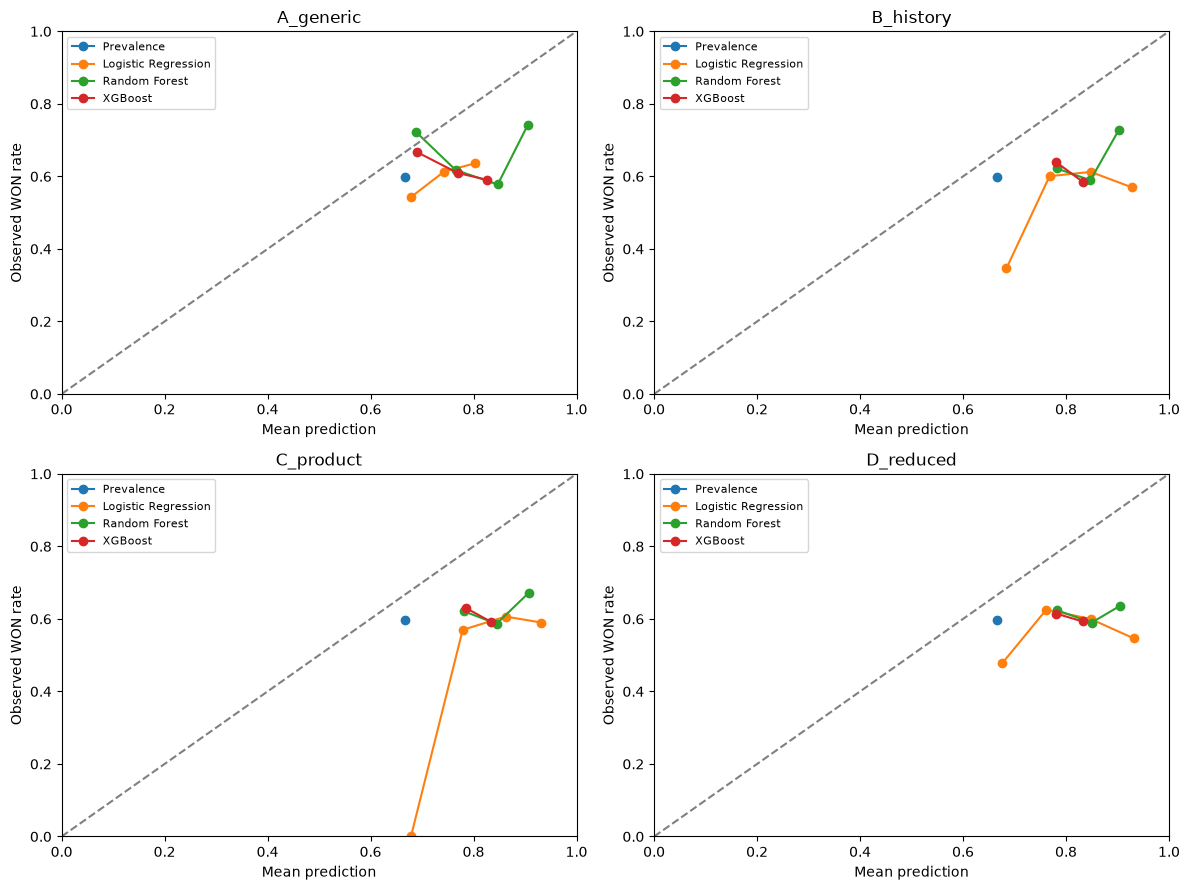

,ROC_AUC,PR_AUC_AP,precision,recall,F1,Brier,p_min,p_max,ECE_10,Brier_skill
candidate,,,,,,,,,,
A_generic / Prevalence,0.5000,0.5978,0.5978,1.0,0.7483,0.2451,0.6663,0.6663,0.0685,0.0000
A_generic / Logistic Regression,0.5416,0.6258,0.5978,1.0,0.7483,0.2564,0.6043,0.8060,0.1312,-0.0459
A_generic / Random Forest,0.4881,0.6053,0.5978,1.0,0.7483,0.2926,0.6684,0.9198,0.2208,-0.1936
A_generic / XGBoost,0.4881,0.5921,0.5978,1.0,0.7483,0.2857,0.6824,0.8665,0.2072,-0.1655
B_history / Prevalence,0.5000,0.5978,0.5978,1.0,0.7483,0.2451,0.6663,0.6663,0.0685,0.0000
B_history / Logistic Regression,0.5018,0.6002,0.5978,1.0,0.7483,0.3011,0.6138,0.9729,0.2404,-0.2283
B_history / Random Forest,0.4859,0.5958,0.5978,1.0,0.7483,0.2982,0.7267,0.9051,0.2351,-0.2167
B_history / XGBoost,0.5064,0.6072,0.5978,1.0,0.7483,0.2909,0.7163,0.8951,0.2225,-0.1868
C_product / Prevalence,0.5000,0.5978,0.5978,1.0,0.7483,0.2451,0.6663,0.6663,0.0685,0.0000


A_generic / Prevalence


,n,predicted,observed
bin,,,
0–10%,0,NaN,NaN
10–20%,0,NaN,NaN
20–30%,0,NaN,NaN
30–40%,0,NaN,NaN
40–50%,0,NaN,NaN
50–60%,0,NaN,NaN
60–70%,1380,0.6663,0.5978
70–80%,0,NaN,NaN
80–90%,0,NaN,NaN


A_generic / Logistic Regression


,n,predicted,observed
bin,,,
0–10%,0,NaN,NaN
10–20%,0,NaN,NaN
20–30%,0,NaN,NaN
30–40%,0,NaN,NaN
40–50%,0,NaN,NaN
50–60%,0,NaN,NaN
60–70%,311,0.6790,0.5434
70–80%,1058,0.7430,0.6134
80–90%,11,0.8038,0.6364


...

D_reduced / Random Forest


,n,predicted,observed
bin,,,
0–10%,0,NaN,NaN
10–20%,0,NaN,NaN
20–30%,0,NaN,NaN
30–40%,0,NaN,NaN
40–50%,0,NaN,NaN
50–60%,0,NaN,NaN
60–70%,0,NaN,NaN
70–80%,266,0.7824,0.6241
80–90%,1070,0.8496,0.5897


D_reduced / XGBoost


,n,predicted,observed
bin,,,
0–10%,0,NaN,NaN
10–20%,0,NaN,NaN
20–30%,0,NaN,NaN
30–40%,0,NaN,NaN
40–50%,0,NaN,NaN
50–60%,0,NaN,NaN
60–70%,0,NaN,NaN
70–80%,314,0.7808,0.6146
80–90%,1066,0.8326,0.5929


Locked model: A_generic / Prevalence | test prevalence: 0.5978260869565217 | mean probability: 0.6662933930571109
Confusion matrix rows/columns [Lost,Won]: [[  0 555]
 [  0 825]]
No calibration refit uses test labels; probability deficiencies are reported rather than hidden.


In [6]:
def reliability(y,p):
    f=pd.DataFrame({'y':np.asarray(y),'p':p})
    f['bin']=pd.cut(f.p,np.linspace(0,1,11),include_lowest=True,labels=[str(i)+'–'+str(i+10)+'%' for i in range(0,100,10)])
    return f.groupby('bin',observed=False).agg(n=('y','size'),predicted=('p','mean'),observed=('y','mean'))
test_predictions={};test_rows=[];calibration_tables={}
baseline_brier=brier_score_loss(test.target,np.full(len(test),train.target.mean()))
fig,axes=plt.subplots(2,2,figsize=(12,9))
for key,(pipe,cols) in fitted_models.items():
    prob=pipe.predict_proba(test[cols])[:,1];test_predictions[key]=prob
    tab=reliability(test.target,prob);calibration_tables[key]=tab
    ece=(tab.n*(tab.predicted-tab.observed).abs()).sum()/len(test)
    test_rows.append({'candidate':key,**evaluate(test.target,prob),'ECE_10':ece,'Brier_skill':1-brier_score_loss(test.target,prob)/baseline_brier})
    ax=axes.flat[list(sets).index(key.split(' / ')[0])]
    nonempty=tab.loc[tab.n>0];ax.plot(nonempty.predicted,nonempty.observed,'o-',label=key.split(' / ')[1])
for ax,title in zip(axes.flat,sets):
    ax.plot([0,1],[0,1],'--',color='grey');ax.set(xlim=(0,1),ylim=(0,1),title=title,xlabel='Mean prediction',ylabel='Observed WON rate');ax.legend(fontsize=8)
plt.tight_layout();plt.show()
test_results=pd.DataFrame(test_rows).set_index('candidate')
display(test_results.round(4))
all_calibration=pd.concat(calibration_tables,names=['candidate','probability_bin'])
for key,tab in calibration_tables.items():
    print(key)
    display(tab.round(4))
final_probability=test_predictions[chosen]
print('Locked model:',chosen,'| test prevalence:',test.target.mean(),'| mean probability:',final_probability.mean())
print('Confusion matrix rows/columns [Lost,Won]:',confusion_matrix(test.target,final_probability>=0.5,labels=[0,1]))
print('No calibration refit uses test labels; probability deficiencies are reported rather than hidden.')

## 7. History value, routing support and frozen-ledger diagnostic
Report no-history / 1–4 / ≥5 account-history populations and A-vs-B performance without implementing artificial routing. If all later records have history, two-mode evaluation is unsupported. The frozen-ledger test recomputes histories using only closes before September 1; the primary rolling ledger includes genuinely observed earlier test closes. This separates operational availability from training leakage.

In [7]:
support_rows=[];subgroup_rows=[]
for name,frame in parts.items():
    bands=pd.cut(frame.account_prior_closed_count,[-1,0,4,np.inf],labels=['none','1–4','5+'])
    for label in bands.cat.categories:
        sub=frame.loc[bands.eq(label)]
        support_rows.append({'partition':name,'account_history':label,'n':len(sub),'won_rate':sub.target.mean()})
        if name=='test' and len(sub)>0:
            for key in ['A_generic / Random Forest','B_history / Random Forest']:
                pipe,cols=fitted_models[key];prob=pipe.predict_proba(sub[cols])[:,1]
                subgroup_rows.append({'candidate':key,'history':label,'n':len(sub),**evaluate(sub.target,prob)})
display(pd.DataFrame(support_rows).round(4))
display(pd.DataFrame(subgroup_rows).round(4))
frozen=add_histories(test,closed.loc[closed.close_date<TEST_CUTOFF])
frozen_rows=[]
for key in ['B_history / Random Forest','C_product / Random Forest','D_reduced / Random Forest']:
    pipe,cols=fitted_models[key]
    frozen_rows.append({'candidate':key,**evaluate(test.target,pipe.predict_proba(frozen[cols])[:,1])})
display(pd.DataFrame(frozen_rows).round(4))
print('Routing is NOT implemented: history availability and subgroup evidence must justify it first.')

,partition,account_history,n,won_rate
0,train,none,1079,0.7257
1,train,1–4,338,0.6864
2,train,5+,1262,0.6101
3,validation,none,0,NaN
4,validation,1–4,0,NaN
5,validation,5+,730,0.5164
6,test,none,0,NaN
7,test,1–4,0,NaN
8,test,5+,1380,0.5978


,candidate,history,n,ROC_AUC,PR_AUC_AP,precision,recall,F1,Brier,p_min,p_max
0,A_generic / Random Forest,5+,1380,0.4881,0.6053,0.5978,1.0,0.7483,0.2926,0.6684,0.9198
1,B_history / Random Forest,5+,1380,0.4859,0.5958,0.5978,1.0,0.7483,0.2982,0.7267,0.9051


,candidate,ROC_AUC,PR_AUC_AP,precision,recall,F1,Brier,p_min,p_max
0,B_history / Random Forest,0.4864,0.5970,0.5978,1.0,0.7483,0.2989,0.7082,0.9067
1,C_product / Random Forest,0.4950,0.6001,0.5978,1.0,0.7483,0.3043,0.7395,0.9234
2,D_reduced / Random Forest,0.4883,0.5962,0.5978,1.0,0.7483,0.3022,0.7157,0.9126


Routing is NOT implemented: history availability and subgroup evidence must justify it first.


## 8. Genuine held-out examples, importance and compact result handoff
Low/middle/high are relative scores selected without looking at outcomes. Show all actual final inputs; if prevalence wins, three records have the same probability and cannot be represented as distinct confidence levels. Permutation importance measures predictive reliance, not causation. Save only compact metrics/calibration/support metadata for the comparison notebook; no serialized executable model or full-row dump.

In [8]:
order=np.argsort(final_probability,kind='stable');positions=[order[0],order[len(order)//2],order[-1]]
examples=test.iloc[positions][['opportunity_id','account','sales_agent','product','engage_date']].copy()
examples['probability']=final_probability[positions];examples['actual']=test.iloc[positions].deal_stage.values
display(examples.reset_index(drop=True))
display(test.iloc[positions][final_cols].T)
from sklearn.inspection import permutation_importance
pi=permutation_importance(final_model,test[final_cols],test.target,scoring='neg_brier_score',n_repeats=5,random_state=42,n_jobs=1)
importance=pd.DataFrame({'feature':final_cols,'Brier_increase':pi.importances_mean,'repeat_sd':pi.importances_std}).sort_values('Brier_increase',ascending=False)
display(importance.round(5).head(15))
import json,hashlib,platform
from importlib.metadata import version
report={'chosen':chosen,'split':split_table.astype(str).reset_index().to_dict('records'),'train_n':len(train),'validation_n':len(validation),'test_n':len(test),'closed_n':len(model),'closed_prevalence':float(model.target.mean()),'test_prevalence':float(test.target.mean()),'baseline_brier':baseline_brier,'final_features':final_cols,'validation':validation_results.reset_index().to_dict('records'),'test':test_results.reset_index().to_dict('records'),'history_support':pd.DataFrame(support_rows).to_dict('records'),'identity_validation':identity_results.reset_index().to_dict('records'),'frozen_test':frozen_rows,'calibration':all_calibration.reset_index().to_dict('records'),'python':platform.python_version(),'packages':{n:version(n) for n in ['numpy','pandas','scikit-learn','matplotlib']},'input_sha256':{n:hashlib.sha256((DATA/(n+'.csv')).read_bytes()).hexdigest() for n in ['accounts','products','sales_pipeline','sales_teams','data_dictionary']}}
if 'XGBoost' in estimators:
    import xgboost
    report['packages']['xgboost']=xgboost.__version__
    report['xgboost_parameters']=estimators['XGBoost'].get_params()
report['evaluation_note']='XGBoost follow-up uses unchanged splits and predefined parameters on an already inspected test period; not a new untouched holdout.'
clean=json.loads(pd.Series(report).to_json(date_format='iso'))
report_path=ROOT/'notebooks'/'maven_evaluation_summary.json'
report_path.write_text(json.dumps(clean,indent=2,allow_nan=False)+'\n')
print('Saved comparison inputs:',report_path.name,'| packages:',report['packages'])
assert set(final_cols).isdisjoint({'opportunity_id','deal_stage','close_date','close_value','target'})

,opportunity_id,account,sales_agent,product,engage_date,probability,actual
0,05HLE3JL,Stanredtax,Anna Snelling,GTX Basic,2017-09-01,0.666293,Won
1,FHCSKQ4K,Bluth Company,Donn Cantrell,GTX Plus Pro,2017-10-01,0.666293,Won
2,W2ZRP2EC,Kan-code,Vicki Laflamme,MG Special,2017-10-31,0.666293,Lost


,4984,5674,6363
sector,finance,technolgy,software
office_location,United States,United States,United States
series,GTX,GTX,MG
revenue,1698.2,1242.32,11698.03
employees,3798.0,3027.0,34288.0
sales_price,550,5482,55
company_age_at_engagement,30.0,24.0,35.0
log_account_revenue,7.437913,7.125541,9.367261
log_employee_count,8.242493,8.015658,10.44258
revenue_per_employee,447130.068457,410412.950116,341169.797014


,feature,Brier_increase,repeat_sd
0,sector,0.0,0.0
1,office_location,0.0,0.0
2,series,0.0,0.0
3,revenue,0.0,0.0
4,employees,0.0,0.0
5,sales_price,0.0,0.0
6,company_age_at_engagement,0.0,0.0
7,log_account_revenue,0.0,0.0
8,log_employee_count,0.0,0.0
9,revenue_per_employee,0.0,0.0


Saved comparison inputs: maven_evaluation_summary.json | packages: {'numpy': '2.5.3', 'pandas': '3.0.6', 'scikit-learn': '1.9.1', 'matplotlib': '3.11.2', 'xgboost': '3.4.1'}


## 9. Nonconstant challenger examples and safety tests
The selected prevalence predictor assigns 66.63% to every opportunity; it has no low/medium/high differentiation and no feature importance. For illustration only, show the best **nonconstant validation-Brier** challenger (not the best test model) with relative low/middle/high scores. This does not promote it to deployment. Test no-history, same-day exclusion and invariance to changing future outcomes.

In [9]:
challenger=next(k for k in validation_results.index if not k.endswith('Prevalence'))
challenge_model,challenge_cols=fitted_models[challenger]
cp=test_predictions[challenger]
idx=np.argsort(cp,kind='stable'); sample_idx=[idx[0],idx[len(idx)//2],idx[-1]]
sample=test.iloc[sample_idx][['opportunity_id','account','sales_agent','product','engage_date']+ [c for c in challenge_cols if c not in ['account','sales_agent','product']]].copy()
sample.insert(0,'relative_score',['lower','middle','higher'])
sample['probability']=cp[sample_idx];sample['actual']=test.iloc[sample_idx].deal_stage.values
print('Illustrative non-deployment challenger:',challenger)
display(sample.T)
pi_ch=permutation_importance(challenge_model,test[challenge_cols],test.target,scoring='neg_brier_score',n_repeats=5,random_state=42,n_jobs=1)
display(pd.DataFrame({'feature':challenge_cols,'Brier_increase':pi_ch.importances_mean,'repeat_sd':pi_ch.importances_std}).sort_values('Brier_increase',ascending=False).head(10).round(5))
probe=test.iloc[[0]].copy();t=probe.engage_date.iloc[0]
changed=closed.copy(); changed.loc[changed.close_date>=t,'target']=1-changed.loc[changed.close_date>=t,'target']
history_columns=[c for c in model if any(c.startswith(p+'_') for p in ['account','agent','product']) and any(s in c for s in ['prior_','history_present','days_since_close'])]
pd.testing.assert_frame_equal(add_histories(probe,closed)[history_columns],add_histories(probe,changed)[history_columns])
empty=add_histories(probe,closed.iloc[:0])
assert empty.account_prior_closed_count.iloc[0]==0 and pd.isna(empty.account_prior_win_rate.iloc[0])
same_day=closed.iloc[[0]].copy()
for key in ['account','sales_agent','product']: same_day[key]=probe[key].iloc[0]
same_day['close_date']=t
assert add_histories(probe,same_day).account_prior_closed_count.iloc[0]==0
print('PASS: future-label changes cannot affect earlier histories; empty histories stay unknown; same-day closes excluded.')

Illustrative non-deployment challenger: A_generic / Logistic Regression


,5942,5882,5458
relative_score,lower,middle,higher
opportunity_id,AK9OXW30,B24YQ6LA,DH8R6PK5
account,Ganjaflex,Zotware,Rangreen
sales_agent,Garret Kinder,Garret Kinder,Darcel Schlecht
product,MG Special,GTX Basic,GTX Pro
engage_date,2017-10-11 00:00:00,2017-10-09 00:00:00,2017-09-23 00:00:00
sector,retail,software,technolgy
office_location,Japan,United States,Panama
series,MG,GTX,GTX
revenue,5158.71,4478.47,2938.67


,feature,Brier_increase,repeat_sd
13,engagement_quarter,0.00525,0.00243
10,log_revenue_per_employee,0.00306,0.00049
3,revenue,0.00212,0.00019
9,revenue_per_employee,0.00133,0.00038
7,log_account_revenue,0.00076,0.00009
8,log_employee_count,0.00068,0.00007
1,office_location,0.00051,0.00046
11,subsidiary_indicator,0.00018,0.00010
5,sales_price,0.00001,0.00001
2,series,0.00000,0.00004


PASS: future-label changes cannot affect earlier histories; empty histories stay unknown; same-day closes excluded.


## XGBoost follow-up — executed
CPU-only XGBoost 3.4.1 was installed into the existing kernel and all code cells rerun. The previously specified configuration was retained: 150 trees, depth 2, learning rate 0.04, min_child_weight 15, reg_lambda 10, subsample/colsample 0.9, histogram trees, seed 42, two CPU threads. No hyperparameter search, class reweighting or split changes.

| XGBoost feature set | Validation Brier | Test ROC-AUC | Test AP | Test Brier | Test probability range | Test 10-bin ECE |
|---|---:|---:|---:|---:|---|---:|
| A generic | 0.3300 | 0.4881 | 0.5921 | 0.2857 | 68.24–86.65% | 20.72 percentage points |
| B history | 0.3362 | 0.5064 | 0.6072 | 0.2909 | 71.63–89.51% | 22.25 points |
| C product | 0.3409 | 0.5113 | 0.6113 | 0.2932 | 74.10–89.97% | 22.87 points |
| D reduced | 0.3388 | 0.5128 | 0.6100 | 0.2908 | 71.19–89.66% | 22.30 points |

All XGBoost variants predict Won at 0.5: precision 0.5978, recall 1.0000 and F1 0.7483, identical to the always-Won classifier. They do not beat prevalence Brier 0.2451 and rank near chance. For example, generic XGBoost's 80–90% bin averages 82.61% predicted but only 59.07% observed across 882 opportunities.

**Decision remains CONTINUE TESTING.** XGBoost does not resolve the weak signal/overconfidence in this evaluation. The model selected by validation Brier remains prevalence. The test period was already inspected before this user-requested extension, so this is a follow-up benchmark—not a new untouched holdout. IBM, CSVs and the React application remain unchanged.